# VISION-L0.6 — ResNet18-2.5D baseline con cohorte oficial RENAL-CORE

Experimento derivado de VISION-L0.4.1. Mantiene el mismo protocolo oficial: cohorte TCGA-KIRC OS-valid, TCIA/NBIA, splits por paciente, PCA ajustada solo en train y Cox ridge.

La única diferencia metodológica principal es que cada vista ya no usa un corte central 2D en escala de grises repetido a 3 canales. Ahora usa una representación 2.5D: tres cortes vecinos alrededor del centro anatómico, codificados como canales RGB.

Objetivo: medir si recuperar contexto local volumétrico mejora el baseline sin pasar todavía a U-Net 3D/STU-Net.

In [1]:
# ============================================================
# 0) Entorno Colab
# ============================================================
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# 1) Dependencias
# ============================================================
import sys, subprocess
from pathlib import Path

marker = Path('/content/.vision_l06_deps_ok') if Path('/content').exists() else Path('/tmp/.vision_l06_deps_ok')
if not marker.exists():
    pkgs = [
        'pydicom',
        'opencv-python-headless',
        'lifelines',
        'tqdm',
        'pandas',
        'numpy',
        'scikit-learn',
        'pillow',
        'requests',
        'matplotlib'
    ]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
    marker.write_text('ok')
print('[OK] dependencias')

[OK] dependencias


In [3]:
# ============================================================
# 2) Imports y configuración global
# ============================================================
import os, json, math, random, shutil, zipfile, warnings, time
from pathlib import Path
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm
from PIL import Image

import pydicom
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from lifelines import CoxPHFitter

import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

CFG = {
    # Rutas compatibles con los notebooks previos
    'drive_project': '/content/drive/MyDrive/datatesis',
    'base_name': 'baseline_resnet18_2p5d_exp6_official444',
    'local_work': '/content/work',

    # Fuente radiológica
    'collection': 'TCGA-KIRC',
    'modalities': ['CT', 'MR'],        # para comparar STU-Net CT-only, cambia a ['CT']
    'prefer_ct': True,
    'min_slices': 16,
    'max_candidate_series_per_patient': 3,
    'max_series_per_patient_final': 1,

    # Control de tamaño. None = intentar todos los elegibles, pero puede ser pesado.
    'target_total_patients': None,
    'patients_to_add_this_run': 300,
    'min_free_gb': 6,

    # Imágenes 2.5D
    'img_size': 224,
    # offsets relativos usados como canales RGB por vista; [-1,0,1] = tres cortes vecinos
    'slice_offsets': [-1, 0, 1],
    'slice_encoding': 'neighbor_stack_rgb',
    'views': ['axial', 'coronal', 'sagittal'],
    'window_low': -150,
    'window_high': 250,
    'force_rebuild_slices': False,
    'force_recompute_features': False,

    # Evaluación survival
    'seed_list': [42, 123, 456, 789, 1024],
    'test_size': 0.20,
    'inner_folds': 3,
    'pca_dims_grid': [4, 8, 16, 24, 32, 48],
    'penalizer_grid': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 20.0],
    'l1_ratio': 0.0,
    'official_main_config': 'mean3',
    'official_secondary_config': 'coronal',

    # Features
    'feature_batch_size': 64,
    'use_imagenet_weights': True,
    'outcomes_filename': 'tcga_kirc_os_official_444.csv',
    'allow_gdc_outcomes_fallback': False,
    'expected_official_n_min': 430,
    'expected_official_n_max': 460,
}

BASE_DIR = Path(CFG['drive_project']) if IN_COLAB else Path('/mnt/data')
DATA_DIR = BASE_DIR / 'data' / 'raw'
EXP4_DIR = BASE_DIR / CFG['base_name']
ARTIFACTS_DIR = EXP4_DIR / 'artifacts'
FEATURES_DIR = EXP4_DIR / 'features'
SPLITS_DIR = EXP4_DIR / 'splits'
DICOM_DIR = DATA_DIR / 'tcga_kirc_tcia_dicom'
SLICES_DIR = EXP4_DIR / 'slices_2p5d_rgb'

for d in [BASE_DIR, DATA_DIR, EXP4_DIR, ARTIFACTS_DIR, FEATURES_DIR, SPLITS_DIR, DICOM_DIR, SLICES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

OUTCOMES_CSV = DATA_DIR / CFG['outcomes_filename']
SERIES_CSV = EXP4_DIR / 'tcia_series_manifest.csv'
CENSUS_CSV = ARTIFACTS_DIR / 'vision_data_census.csv'
SERIES_CANDIDATES_CSV = ARTIFACTS_DIR / 'series_candidates_ranked.csv'
EXTRACTION_ATTEMPTS_CSV = ARTIFACTS_DIR / 'image_extraction_attempts.csv'
SLICES_CSV = EXP4_DIR / 'slices_manifest.csv'
FEATURES_CSV = FEATURES_DIR / 'frozen_resnet18_2p5d_rgb_features_512.csv'

with open(EXP4_DIR / 'config_exp6.json', 'w') as f:
    json.dump(CFG, f, indent=2)

print('BASE_DIR:', BASE_DIR)
print('EXP4_DIR:', EXP4_DIR)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

BASE_DIR: /content/drive/MyDrive/datatesis
EXP4_DIR: /content/drive/MyDrive/datatesis/baseline_resnet18_2p5d_exp6_official444
CUDA: True
GPU: Tesla T4


In [4]:
# ============================================================
# 3) Utilidades generales
# ============================================================
def safe_int(x):
    try:
        if x in [None, '', 'NA', 'NaN']:
            return None
        return int(float(x))
    except Exception:
        return None


def disk_free_gb(path='/content'):
    if not Path(path).exists(): path = '/'
    total, used, free = shutil.disk_usage(path)
    return free / (1024**3)


def assert_local(min_gb=None):
    min_gb = CFG['min_free_gb'] if min_gb is None else min_gb
    free = disk_free_gb('/content')
    if free < min_gb:
        raise RuntimeError(f'Espacio libre bajo en /content: {free:.2f} GB. Baja patients_to_add_this_run o libera espacio.')
    return free


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def harrell_cindex(times, events, risks) -> Tuple[float, int]:
    times = np.asarray(times, dtype=float)
    events = np.asarray(events, dtype=int)
    risks = np.asarray(risks, dtype=float)
    concordant = 0.0
    permissible = 0
    n = len(times)
    for i in range(n):
        for j in range(i + 1, n):
            if times[i] == times[j]:
                continue
            if events[i] == 1 and times[i] < times[j]:
                permissible += 1
                if risks[i] > risks[j]: concordant += 1
                elif risks[i] == risks[j]: concordant += 0.5
            elif events[j] == 1 and times[j] < times[i]:
                permissible += 1
                if risks[j] > risks[i]: concordant += 1
                elif risks[j] == risks[i]: concordant += 0.5
    if permissible == 0:
        return np.nan, 0
    return float(concordant / permissible), int(permissible)


def bootstrap_cindex_ci(times, events, risks, n_boot=500, seed=42):
    rng = np.random.default_rng(seed)
    times = np.asarray(times); events = np.asarray(events); risks = np.asarray(risks)
    n = len(times)
    vals = []
    for _ in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        c, pairs = harrell_cindex(times[idx], events[idx], risks[idx])
        if np.isfinite(c) and pairs > 0:
            vals.append(c)
    if len(vals) < 30:
        return np.nan, np.nan
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

## 4) Outcomes oficiales TCGA-KIRC

Este bloque busca primero el archivo oficial del cohorte doctoral. Si no existe, se detiene por defecto. Esto evita mezclar la cohorte GDC permisiva (~526 pacientes) con el cohorte curado de RENAL-CORE (~444 pacientes).

In [5]:
# ============================================================
# 4) Outcomes oficiales TCGA-KIRC
# ============================================================
def standardize_outcomes(df):
    df = df.copy()
    lower = {c.lower(): c for c in df.columns}
    if {'case_id', 'os_time', 'os_event'} <= set(df.columns):
        out = df[['case_id', 'os_time', 'os_event']].copy()
    elif {'bcr_patient_barcode', 'os_time', 'os_event'} <= set(lower.keys()):
        out = pd.DataFrame({
            'case_id': df[lower['bcr_patient_barcode']].astype(str).str.strip().str.upper().str[:12],
            'os_time': df[lower['os_time']],
            'os_event': df[lower['os_event']],
        })
    elif {'sample', 'os.time', 'os'} <= set(lower.keys()):
        out = pd.DataFrame({
            'case_id': df[lower['sample']].astype(str).str.strip().str.upper().str[:12],
            'os_time': df[lower['os.time']],
            'os_event': df[lower['os']],
        })
    elif {'case_id', 'survival_days', 'event'} <= set(df.columns):
        out = df[['case_id', 'survival_days', 'event']].copy()
        out = out.rename(columns={'survival_days': 'os_time', 'event': 'os_event'})
    else:
        raise ValueError(f'No reconozco columnas de outcomes: {df.columns.tolist()}')
    out['case_id'] = out['case_id'].astype(str).str.strip().str.upper().str[:12]
    out['os_time'] = pd.to_numeric(out['os_time'], errors='coerce')
    out['os_event'] = pd.to_numeric(out['os_event'], errors='coerce').fillna(0).astype(int)
    out = out.dropna(subset=['case_id', 'os_time'])
    out = out[out['os_time'] > 0]
    out = out[out['os_event'].isin([0, 1])]
    out = out.drop_duplicates('case_id')
    return out.reset_index(drop=True)


def download_gdc_kirc_outcomes(out_csv=OUTCOMES_CSV):
    print('[INFO] Descargando outcomes básicos desde GDC API...')
    url = 'https://api.gdc.cancer.gov/cases'
    filters = {'op':'and','content':[{'op':'in','content':{'field':'project.project_id','value':['TCGA-KIRC']}}]}
    fields = ','.join(['submitter_id','demographic.vital_status','diagnoses.days_to_death','diagnoses.days_to_last_follow_up'])
    params = {'filters': json.dumps(filters), 'fields': fields, 'format': 'JSON', 'size': '1000'}
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    hits = r.json()['data']['hits']
    rows = []
    for h in hits:
        case_id = h.get('submitter_id', '')[:12]
        vital = (h.get('demographic') or {}).get('vital_status', '')
        event = 1 if str(vital).lower() == 'dead' else 0
        diagnoses = h.get('diagnoses') or []
        diag = diagnoses[0] if diagnoses else {}
        dtd = safe_int(diag.get('days_to_death'))
        dtlf = safe_int(diag.get('days_to_last_follow_up'))
        os_time = dtd if event and dtd is not None else dtlf
        if os_time is None or os_time <= 0:
            continue
        rows.append({'case_id': case_id, 'os_time': os_time, 'os_event': event})
    out = pd.DataFrame(rows).drop_duplicates('case_id')
    out.to_csv(out_csv, index=False)
    print(f'[OK] outcomes GDC guardados: {out_csv} | n={len(out)}')
    return out

# Candidatos comunes para el cohorte oficial.
outcome_candidates = [
    OUTCOMES_CSV,
    DATA_DIR / 'tcga_kirc_os_official_444.csv',
    DATA_DIR / 'tcga_kirc_os_444.csv',
    DATA_DIR / 'tcga_kirc_survival_444.csv',
    BASE_DIR / 'clinical_core' / 'data' / 'processed' / 'tcga_kirc_os_444.csv',
    BASE_DIR / 'clinical_core' / 'data' / 'processed' / 'tcga_kirc_cohort_444.csv',
]

selected_outcome_path = None
for p in outcome_candidates:
    if Path(p).exists():
        selected_outcome_path = Path(p)
        break

if selected_outcome_path is not None:
    outcomes = standardize_outcomes(pd.read_csv(selected_outcome_path))
    print(f'[OK] outcomes oficiales encontrados: {selected_outcome_path} | n={len(outcomes)}')
elif CFG.get('allow_gdc_outcomes_fallback', False):
    print('[WARN] No encontré outcomes oficiales. Usando GDC fallback solo para smoke test.')
    outcomes = standardize_outcomes(download_gdc_kirc_outcomes(OUTCOMES_CSV))
    selected_outcome_path = OUTCOMES_CSV
else:
    raise FileNotFoundError(
        'No encontré el CSV oficial de outcomes. Colócalo en:\n'
        f'  {OUTCOMES_CSV}\n'
        'con columnas: case_id, os_time, os_event.\n'
        'Si solo quieres smoke test, cambia allow_gdc_outcomes_fallback=True en CFG.'
    )

n = outcomes.shape[0]
lo, hi = CFG['expected_official_n_min'], CFG['expected_official_n_max']
if not (lo <= n <= hi):
    print(f'[WARN] El tamaño del cohorte ({n}) no está en el rango esperado [{lo}, {hi}].')
    print('       Para resultados oficiales, verifica que este CSV corresponda al runner RENAL-CORE.')
else:
    print('[OK] Tamaño compatible con cohorte oficial RENAL-CORE.')

print('Pacientes OS-valid:', outcomes.shape[0])
print(outcomes['os_event'].value_counts().rename(index={0:'censored',1:'event'}))
display(outcomes.head())

[OK] outcomes oficiales encontrados: /content/drive/MyDrive/datatesis/data/raw/tcga_kirc_os_official_444.csv | n=444
[OK] Tamaño compatible con cohorte oficial RENAL-CORE.
Pacientes OS-valid: 444
os_event
censored    305
event       139
Name: count, dtype: int64


,case_id,os_time,os_event
0,TCGA-3Z-A93Z,4.0,0
1,TCGA-6D-AA2E,135.0,0
2,TCGA-A3-3306,1120.0,0
3,TCGA-A3-3308,16.0,0
4,TCGA-A3-3311,1191.0,1


## 5) Censo TCIA/NBIA y ranking de series

Este bloque consulta series públicas de TCIA/NBIA, las cruza contra outcomes y crea un censo. La selección intenta hasta `max_candidate_series_per_patient` series por paciente para no perder casos cuando la primera serie falla.

In [6]:
# ============================================================
# 5) Censo TCIA/NBIA y ranking de series
# ============================================================
def get_tcia_series(collection='TCGA-KIRC', save_csv=SERIES_CSV):
    if Path(save_csv).exists():
        df = pd.read_csv(save_csv)
        print(f'[OK] manifest TCIA existente: {save_csv} | series={len(df)}')
        return df
    print('[INFO] Consultando series públicas en TCIA/NBIA...')
    url = 'https://services.cancerimagingarchive.net/nbia-api/services/v1/getSeries'
    r = requests.get(url, params={'Collection': collection}, timeout=120)
    r.raise_for_status()
    df = pd.DataFrame(r.json())
    if len(df) == 0:
        raise RuntimeError('TCIA no devolvió series. Revisa colección o red.')
    df.to_csv(save_csv, index=False)
    print(f'[OK] manifest TCIA guardado: {save_csv} | series={len(df)}')
    return df

series = get_tcia_series(CFG['collection'], SERIES_CSV)
series['case_id'] = series.get('PatientID', '').astype(str).str[:12]
series['Modality'] = series.get('Modality', '').astype(str).str.upper()
series['ImageCount_num'] = pd.to_numeric(series.get('ImageCount', 0), errors='coerce').fillna(0).astype(int)

for col in ['SeriesDescription', 'StudyDescription', 'BodyPartExamined', 'Manufacturer', 'ProtocolName']:
    if col not in series.columns:
        series[col] = ''
    series[col] = series[col].fillna('').astype(str)

text_cols = ['SeriesDescription', 'StudyDescription', 'BodyPartExamined', 'ProtocolName']
series['series_text'] = series[text_cols].agg(' '.join, axis=1).str.lower()

series['has_outcome'] = series['case_id'].isin(outcomes['case_id'])
series['modality_ok'] = series['Modality'].isin(CFG['modalities'])
series['slices_ok'] = series['ImageCount_num'] >= CFG['min_slices']
series['abdomen_hint'] = series['series_text'].str.contains('abd|renal|kidney|pelv|uro|neph|retroperitone', regex=True)
series['bad_hint'] = series['series_text'].str.contains('localizer|scout|topogram|dose|report|screen|seg', regex=True)

eligible = series[series['has_outcome'] & series['modality_ok'] & series['slices_ok'] & (~series['bad_hint'])].copy()

# Ranking: CT primero, abdomen/renal primero, más cortes primero.
eligible['modality_rank'] = eligible['Modality'].map({'CT':0, 'MR':1}).fillna(9) if CFG['prefer_ct'] else 0
eligible['anatomy_rank'] = np.where(eligible['abdomen_hint'], 0, 1)
eligible = eligible.sort_values(['case_id','modality_rank','anatomy_rank','ImageCount_num'], ascending=[True, True, True, False])
eligible['candidate_rank'] = eligible.groupby('case_id').cumcount() + 1
candidates = eligible[eligible['candidate_rank'] <= CFG['max_candidate_series_per_patient']].copy()
candidates.to_csv(SERIES_CANDIDATES_CSV, index=False)

census_rows = []
census_rows.append({'stage':'outcomes_os_valid', 'n_patients': outcomes['case_id'].nunique(), 'n_series': np.nan})
census_rows.append({'stage':'tcia_any_series', 'n_patients': series['case_id'].nunique(), 'n_series': len(series)})
census_rows.append({'stage':'outcome_and_tcia_any', 'n_patients': series.loc[series['has_outcome'], 'case_id'].nunique(), 'n_series': int(series['has_outcome'].sum())})
census_rows.append({'stage':'modality_ok', 'n_patients': series.loc[series['has_outcome'] & series['modality_ok'], 'case_id'].nunique(), 'n_series': int((series['has_outcome'] & series['modality_ok']).sum())})
census_rows.append({'stage':'min_slices_ok', 'n_patients': series.loc[series['has_outcome'] & series['modality_ok'] & series['slices_ok'], 'case_id'].nunique(), 'n_series': int((series['has_outcome'] & series['modality_ok'] & series['slices_ok']).sum())})
census_rows.append({'stage':'eligible_not_bad_hint', 'n_patients': eligible['case_id'].nunique(), 'n_series': len(eligible)})
census = pd.DataFrame(census_rows)
census.to_csv(CENSUS_CSV, index=False)

display(census)
print('Candidatos rankeados:', candidates['case_id'].nunique(), 'pacientes |', len(candidates), 'series')
display(candidates[['case_id','candidate_rank','Modality','ImageCount_num','abdomen_hint','SeriesInstanceUID','SeriesDescription']].head(20))

[INFO] Consultando series públicas en TCIA/NBIA...
[OK] manifest TCIA guardado: /content/drive/MyDrive/datatesis/baseline_resnet18_2p5d_exp6_official444/tcia_series_manifest.csv | series=2654


,stage,n_patients,n_series
0,outcomes_os_valid,444,NaN
1,tcia_any_series,267,2654.0
2,outcome_and_tcia_any,214,2180.0
3,modality_ok,214,2176.0
4,min_slices_ok,214,1750.0
5,eligible_not_bad_hint,214,1703.0


Candidatos rankeados: 214 pacientes | 608 series


,case_id,candidate_rank,Modality,ImageCount_num,abdomen_hint,SeriesInstanceUID,SeriesDescription
782,TCGA-B0-4698,1,CT,56,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.173860966071...,+C
852,TCGA-B0-4713,1,CT,190,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.265349325173...,WITH AND DELAY
853,TCGA-B0-4713,2,CT,93,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.318185778053...,Recon 2: WITH AND DELAY
851,TCGA-B0-4713,3,CT,92,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.193245818439...,W/O ABD PELVIS
778,TCGA-B0-4821,1,CT,244,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.365655763318...,
776,TCGA-B0-4821,2,CT,122,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.197843508979...,
777,TCGA-B0-4821,3,CT,106,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.304298305055...,
780,TCGA-B0-4833,1,CT,60,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.175542747344...,+C
766,TCGA-B0-4839,1,CT,48,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.170990576592...,
827,TCGA-B0-4843,1,CT,142,True,1.3.6.1.4.1.14519.5.2.1.6450.4004.153353871242...,


## 6) Migrar/reutilizar slices existentes

Este bloque busca `slices_manifest.csv` de versiones anteriores y copia sus filas válidas. Así no perdemos los 117 pacientes ya procesados.

In [7]:
# ============================================================
# 6) Reutilizar slices 2.5D existentes de este experimento
# ============================================================
# Importante: no reutilizamos manifests 2D previos porque este experimento cambia
# la representación de entrada. Las imágenes 2.5D son RGB con canales = cortes vecinos.

def normalize_outcome_columns(df, name="df"):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    rename_map = {}
    if 'survival_days' in df.columns and 'os_time' not in df.columns:
        rename_map['survival_days'] = 'os_time'
    if 'event' in df.columns and 'os_event' not in df.columns:
        rename_map['event'] = 'os_event'
    if rename_map:
        df = df.rename(columns=rename_map)
    required = {'case_id', 'os_time', 'os_event'}
    missing = required - set(df.columns)
    if missing:
        print(f'Columnas disponibles en {name}:', list(df.columns))
        raise KeyError(f'{name} no tiene columnas requeridas: {missing}')
    df['case_id'] = df['case_id'].astype(str).str.strip().str.upper().str[:12]
    df['os_time'] = pd.to_numeric(df['os_time'], errors='coerce')
    df['os_event'] = pd.to_numeric(df['os_event'], errors='coerce')
    df = df.dropna(subset=['case_id', 'os_time', 'os_event'])
    df = df[df['os_time'] > 0].copy()
    df['os_event'] = df['os_event'].astype(int)
    return df[['case_id','os_time','os_event']].drop_duplicates('case_id')

outcomes_clean = normalize_outcome_columns(outcomes, 'outcomes')
outcomes = outcomes_clean.copy()

if SLICES_CSV.exists() and not CFG['force_rebuild_slices']:
    existing_slices = pd.read_csv(SLICES_CSV)
    existing_slices['case_id'] = existing_slices['case_id'].astype(str).str.strip().str.upper().str[:12]
    existing_slices['view'] = existing_slices['view'].astype(str).str.lower().str.strip()
    existing_slices = existing_slices[existing_slices['view'].isin(CFG['views'])].copy()
    existing_slices = existing_slices[existing_slices['image_path'].map(lambda p: Path(str(p)).exists())].copy()
    # Evitar duplicados de outcomes si el manifest ya los traía de una corrida anterior.
    old_outcome_cols = ['os_time','os_event','survival_days','event','os_time_x','os_time_y','os_event_x','os_event_y']
    existing_slices = existing_slices.drop(columns=[c for c in old_outcome_cols if c in existing_slices.columns], errors='ignore')
    existing_slices = existing_slices.merge(outcomes_clean, on='case_id', how='inner', validate='many_to_one')
else:
    existing_slices = pd.DataFrame(columns=['case_id','view','image_path','os_time','os_event'])

complete_existing = existing_slices.groupby('case_id')['view'].nunique() if len(existing_slices) else pd.Series(dtype=int)
complete_existing_ids = set(complete_existing[complete_existing == len(CFG['views'])].index)
print('Slices 2.5D existentes válidos:', len(existing_slices), '| pacientes completos:', len(complete_existing_ids))
if len(existing_slices):
    display(existing_slices.groupby('view')['case_id'].nunique().reset_index(name='patients'))

Slices 2.5D existentes válidos: 0 | pacientes completos: 0


## 7) Descarga DICOM y extracción 2.5D

Cada vista se codifica como RGB: canal 0 = corte anterior/previo, canal 1 = corte central, canal 2 = corte posterior/siguiente.

In [8]:
# ============================================================
# 7) DICOM download + extracción a vistas 2.5D
# ============================================================
def series_has_dicoms(series_dir):
    p = Path(series_dir)
    if not p.exists(): return False
    if len(list(p.rglob('*.dcm'))) > 0: return True
    return len([x for x in p.rglob('*') if x.is_file() and x.name != 'series.zip']) > 5


def download_tcia_series(series_uid, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if series_has_dicoms(out_dir):
        return True, 'exists'
    url = 'https://services.cancerimagingarchive.net/nbia-api/services/v1/getImage'
    tmp_zip = out_dir / 'series.zip'
    try:
        with requests.get(url, params={'SeriesInstanceUID': series_uid}, stream=True, timeout=300) as r:
            r.raise_for_status()
            with open(tmp_zip, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    if chunk: f.write(chunk)
        with zipfile.ZipFile(tmp_zip, 'r') as z:
            z.extractall(out_dir)
        tmp_zip.unlink(missing_ok=True)
        return True, 'downloaded'
    except Exception as e:
        tmp_zip.unlink(missing_ok=True)
        return False, repr(e)


def dicom_sort_key(ds):
    try:
        ipp = ds.get('ImagePositionPatient', None)
        if ipp is not None: return float(ipp[2])
    except Exception: pass
    try: return float(ds.get('InstanceNumber', 0))
    except Exception: return 0.0


def load_dicom_volume(series_dir):
    files = list(Path(series_dir).rglob('*.dcm'))
    if not files:
        files = [p for p in Path(series_dir).rglob('*') if p.is_file() and p.name != 'series.zip']
    loaded = []
    for f in files:
        try:
            ds = pydicom.dcmread(str(f), force=True)
            if not hasattr(ds, 'PixelData'): continue
            arr = ds.pixel_array.astype(np.float32)
            slope = float(getattr(ds, 'RescaleSlope', 1.0))
            intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
            arr = arr * slope + intercept
            if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
                arr = arr.max() - arr
            loaded.append((dicom_sort_key(ds), arr))
        except Exception:
            continue
    if len(loaded) < CFG['min_slices']:
        raise RuntimeError(f'Muy pocos cortes DICOM válidos: {len(loaded)}')
    loaded = sorted(loaded, key=lambda x: x[0])
    vol = np.stack([x[1] for x in loaded], axis=0)
    return vol


def slice_to_uint8(arr, modality='CT'):
    arr = arr.astype(np.float32)
    if str(modality).upper() == 'CT':
        lo, hi = CFG['window_low'], CFG['window_high']
    else:
        lo, hi = np.percentile(arr, [1, 99])
        if hi <= lo: lo, hi = float(arr.min()), float(arr.max())
    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / max(hi - lo, 1e-6)
    return (arr * 255).astype(np.uint8)


def clamp_index(i, n):
    return int(max(0, min(n - 1, i)))


def get_plane(vol, view_name, center_idx, offset):
    z, y, x = vol.shape
    if view_name == 'axial':
        idx = clamp_index(center_idx + offset, z)
        return vol[idx, :, :], idx
    if view_name == 'coronal':
        idx = clamp_index(center_idx + offset, y)
        return vol[:, idx, :], idx
    if view_name == 'sagittal':
        idx = clamp_index(center_idx + offset, x)
        return vol[:, :, idx], idx
    raise ValueError(view_name)


def central_25d_views(vol, modality):
    """Devuelve tres vistas 2.5D. Cada imagen RGB codifica tres cortes vecinos.

    axial: canales = z-1, z, z+1
    coronal: canales = y-1, y, y+1
    sagittal: canales = x-1, x, x+1
    """
    z, y, x = vol.shape
    centers = {'axial': z // 2, 'coronal': y // 2, 'sagittal': x // 2}
    views = {}
    meta = {}
    offsets = list(CFG['slice_offsets'])
    if len(offsets) != 3:
        raise ValueError('Este notebook usa exactamente 3 offsets para codificarlos como canales RGB. Usa [-1,0,1].')
    for view_name, center in centers.items():
        channels, indices = [], []
        for off in offsets:
            plane, idx = get_plane(vol, view_name, center, int(off))
            channels.append(slice_to_uint8(plane, modality=modality))
            indices.append(idx)
        img_rgb = np.stack(channels, axis=-1)  # H x W x 3
        views[view_name] = img_rgb
        meta[view_name] = {'center_index': center, 'slice_indices': indices}
    return views, meta


def resize_and_save(img, out_path):
    img = cv2.resize(img, (CFG['img_size'], CFG['img_size']), interpolation=cv2.INTER_AREA)
    Image.fromarray(img).save(out_path)


def extract_views_from_series(case_id, uid, modality, series_dir):
    vol = load_dicom_volume(series_dir)
    views, meta = central_25d_views(vol, modality=modality)
    rows = []
    for view_name, img in views.items():
        out_dir = SLICES_DIR / view_name
        out_dir.mkdir(parents=True, exist_ok=True)
        out_png = out_dir / f'{case_id}_{view_name}_2p5d_rgb.png'
        resize_and_save(img, out_png)
        rows.append({
            'case_id': case_id, 'view': view_name, 'image_path': str(out_png),
            'SeriesInstanceUID': uid, 'Modality': modality,
            'depth': vol.shape[0], 'height': vol.shape[1], 'width': vol.shape[2],
            'slice_encoding': CFG['slice_encoding'],
            'slice_offsets': json.dumps(CFG['slice_offsets']),
            'center_index': int(meta[view_name]['center_index']),
            'slice_indices': json.dumps([int(v) for v in meta[view_name]['slice_indices']])
        })
    return rows

# Decidir qué pacientes agregar.
all_candidate_ids = list(candidates['case_id'].drop_duplicates())
remaining_ids = [c for c in all_candidate_ids if c not in complete_existing_ids]
if CFG['target_total_patients'] is None:
    target_missing = len(remaining_ids)
else:
    target_missing = max(0, int(CFG['target_total_patients']) - len(complete_existing_ids))
patients_to_add = remaining_ids[:min(target_missing, int(CFG['patients_to_add_this_run']))]
print('Pacientes completos existentes:', len(complete_existing_ids))
print('Pacientes candidatos restantes:', len(remaining_ids))
print('Pacientes a intentar en esta corrida:', len(patients_to_add))

slice_rows = existing_slices.to_dict('records') if len(existing_slices) else []
attempt_rows = []

for case_id in tqdm(patients_to_add, desc='Nuevos pacientes 2.5D'):
    patient_candidates = candidates[candidates['case_id'] == case_id].sort_values('candidate_rank')
    success = False
    for _, row in patient_candidates.iterrows():
        assert_local()
        uid = row['SeriesInstanceUID']
        modality = row.get('Modality', '')
        series_dir = DICOM_DIR / case_id / uid
        ok, status = download_tcia_series(uid, series_dir)
        attempt = {
            'case_id': case_id, 'SeriesInstanceUID': uid, 'candidate_rank': int(row['candidate_rank']),
            'Modality': modality, 'ImageCount_num': int(row.get('ImageCount_num', 0)),
            'dicom_dir': str(series_dir), 'download_ok': bool(ok), 'download_status': status,
            'extract_ok': False, 'failure_reason': ''
        }
        if ok:
            try:
                rows = extract_views_from_series(case_id, uid, modality, series_dir)
                slice_rows.extend(rows)
                attempt['extract_ok'] = True
                success = True
                attempt_rows.append(attempt)
                break
            except Exception as e:
                attempt['failure_reason'] = repr(e)
        attempt_rows.append(attempt)
    if not success:
        pass

slices = pd.DataFrame(slice_rows)
if len(slices):
    slices['case_id'] = slices['case_id'].astype(str).str.strip().str.upper().str[:12]
    slices['view'] = slices['view'].astype(str).str.lower().str.strip()
    slices = slices[slices['view'].isin(CFG['views'])].copy()
    slices = slices[slices['image_path'].map(lambda p: Path(str(p)).exists())].copy()
    slices = slices.drop_duplicates(['case_id','view'], keep='last')

    # Evitar os_event_x/os_event_y si se mezcla con manifests viejos del mismo experimento.
    old_outcome_cols = ['os_time','os_event','survival_days','event','os_time_x','os_time_y','os_event_x','os_event_y']
    slices = slices.drop(columns=[c for c in old_outcome_cols if c in slices.columns], errors='ignore')
    slices = slices.merge(outcomes_clean, on='case_id', how='inner', validate='many_to_one')

    view_counts = slices.groupby('case_id')['view'].nunique()
    complete_ids = set(view_counts[view_counts == len(CFG['views'])].index)
    slices = slices[slices['case_id'].isin(complete_ids)].copy()
else:
    slices = pd.DataFrame(columns=['case_id','view','image_path','os_time','os_event'])

attempt_df = pd.DataFrame(attempt_rows)
attempt_df.to_csv(EXTRACTION_ATTEMPTS_CSV, index=False)
slices.to_csv(SLICES_CSV, index=False)

# Actualizar censo con el resultado usable.
final_census = pd.concat([census, pd.DataFrame([{'stage':'usable_3view_2p5d_slices', 'n_patients': slices['case_id'].nunique(), 'n_series': len(slices)}])], ignore_index=True)
final_census.to_csv(CENSUS_CSV, index=False)

print('[OK] slices 2.5D completos:', len(slices), 'filas | pacientes:', slices['case_id'].nunique())
print('[OK] eventos vision:', int(slices.drop_duplicates('case_id')['os_event'].sum()))
display(final_census)
if len(attempt_df):
    display(attempt_df.groupby(['download_ok','extract_ok']).size().reset_index(name='n'))

Pacientes completos existentes: 0
Pacientes candidatos restantes: 214
Pacientes a intentar en esta corrida: 214


Nuevos pacientes 2.5D:   0%|          | 0/214 [00:00<?, ?it/s]

[OK] slices 2.5D completos: 642 filas | pacientes: 214
[OK] eventos vision: 64


,stage,n_patients,n_series
0,outcomes_os_valid,444,NaN
1,tcia_any_series,267,2654.0
2,outcome_and_tcia_any,214,2180.0
3,modality_ok,214,2176.0
4,min_slices_ok,214,1750.0
5,eligible_not_bad_hint,214,1703.0
6,usable_3view_2p5d_slices,214,642.0


,download_ok,extract_ok,n
0,True,False,4
1,True,True,214


## 8) Vista rápida de slices 2.5D

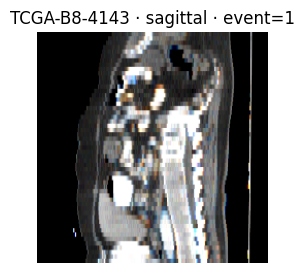

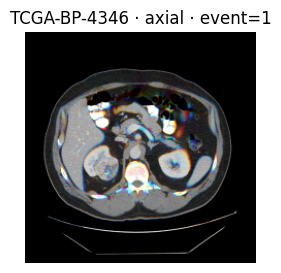

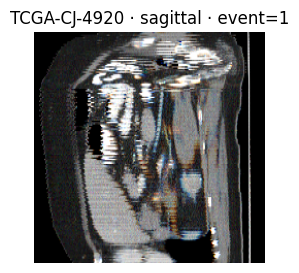

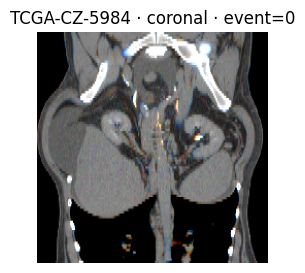

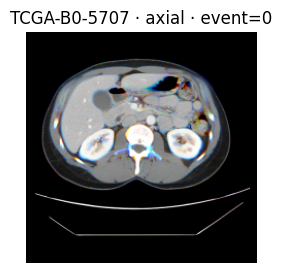

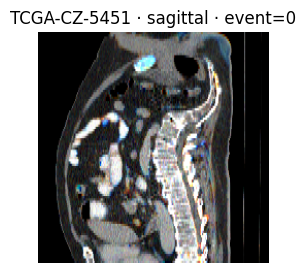

In [9]:
# ============================================================
# 8) Sanity visual
# ============================================================
assert len(slices) > 0, 'No hay slices completos. Revisa censo y extraction_attempts.'

sample = slices.sample(min(6, len(slices)), random_state=42)
for _, r in sample.iterrows():
    img = Image.open(r['image_path'])
    plt.figure(figsize=(3,3))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"{r['case_id']} · {r['view']} · event={r['os_event']}")
    plt.show()

## 9) ResNet18 congelada sobre imágenes 2.5D RGB

In [10]:
# ============================================================
# 9) Feature extraction incremental: ResNet18 frozen sobre imágenes 2.5D RGB
# ============================================================
class SliceImageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True).copy()
        self.tf = transforms.Compose([
            # La imagen ya es RGB 2.5D: cada canal es un corte vecino.
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = Image.open(r['image_path']).convert('RGB')
        return self.tf(img), r['case_id'], r['view'], r['image_path']


def build_resnet18_feature_extractor(use_imagenet=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_imagenet else None
    m = models.resnet18(weights=weights)
    backbone = nn.Sequential(*list(m.children())[:-1])
    backbone.eval()
    for p in backbone.parameters(): p.requires_grad = False
    return backbone


def load_existing_feature_caches():
    # Solo reutilizamos features de este experimento. No mezclamos con 2D central slices.
    if FEATURES_CSV.exists() and not CFG['force_recompute_features']:
        try:
            df = pd.read_csv(FEATURES_CSV)
            if {'case_id','view','image_path'} <= set(df.columns):
                fcols = [c for c in df.columns if c.startswith('f')]
                if len(fcols) >= 128:
                    print('[CACHE]', FEATURES_CSV, 'rows=', len(df))
                    return df[['case_id','view','image_path'] + fcols].copy()
        except Exception:
            pass
    return pd.DataFrame(columns=['case_id','view','image_path'])

need_keys = set(zip(slices['case_id'], slices['view'], slices['image_path']))
cache_df = load_existing_feature_caches()
have_keys = set(zip(cache_df.get('case_id', []), cache_df.get('view', []), cache_df.get('image_path', [])))
missing_df = slices[[k not in have_keys for k in zip(slices['case_id'], slices['view'], slices['image_path'])]].copy()
print('Features needed:', len(slices), '| cached:', len(need_keys & have_keys), '| missing:', len(missing_df))

new_feat_rows = []
if len(missing_df):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    backbone = build_resnet18_feature_extractor(CFG['use_imagenet_weights']).to(device)
    loader = DataLoader(SliceImageDataset(missing_df), batch_size=CFG['feature_batch_size'], shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    with torch.no_grad():
        for x, case_ids, views, paths in tqdm(loader, desc='ResNet18 frozen 2.5D features missing'):
            x = x.to(device)
            h = backbone(x).flatten(1).detach().cpu().numpy()
            for i in range(h.shape[0]):
                row = {'case_id': case_ids[i], 'view': views[i], 'image_path': paths[i]}
                for j in range(h.shape[1]): row[f'f{j:03d}'] = float(h[i,j])
                new_feat_rows.append(row)

new_feat_df = pd.DataFrame(new_feat_rows)
if len(new_feat_df) == 0:
    new_feat_df = pd.DataFrame(columns=cache_df.columns)

features_df = pd.concat([cache_df, new_feat_df], ignore_index=True)
features_df = features_df[features_df['image_path'].isin(slices['image_path'])].copy()
features_df = features_df.drop_duplicates(['case_id','view','image_path'], keep='last')
features_df = features_df.merge(slices[['case_id','view','image_path','os_time','os_event']], on=['case_id','view','image_path'], how='inner', validate='one_to_one')
features_df.to_csv(FEATURES_CSV, index=False)

feature_cols = [c for c in features_df.columns if c.startswith('f')]
print('[OK] features:', len(feature_cols), '| filas:', len(features_df), '| pacientes:', features_df['case_id'].nunique())
display(features_df.head())

Features needed: 642 | cached: 0 | missing: 642
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


ResNet18 frozen 2.5D features missing:   0%|          | 0/11 [00:00<?, ?it/s]

[OK] features: 512 | filas: 642 | pacientes: 214


,case_id,view,image_path,f000,f001,f002,f003,f004,f005,f006,...,f504,f505,f506,f507,f508,f509,f510,f511,os_time,os_event
0,TCGA-B0-4698,axial,/content/drive/MyDrive/datatesis/baseline_resn...,3.361178,0.166188,0.217289,0.660326,0.390704,0.351367,1.581368,...,3.380627,0.212431,1.566883,4.044360,1.107481,0.102973,0.810345,0.291549,42.0,1
1,TCGA-B0-4698,coronal,/content/drive/MyDrive/datatesis/baseline_resn...,0.861547,2.505048,1.934722,0.397175,0.287041,0.023393,1.713954,...,0.827792,0.986350,0.892011,3.835231,1.356505,2.781784,0.396042,1.585304,42.0,1
2,TCGA-B0-4698,sagittal,/content/drive/MyDrive/datatesis/baseline_resn...,1.274607,0.585489,1.833141,0.636705,1.667859,0.044553,0.748986,...,0.659199,0.934484,0.373165,2.354510,3.151670,2.034310,0.441712,1.930184,42.0,1
3,TCGA-B0-4713,axial,/content/drive/MyDrive/datatesis/baseline_resn...,2.573855,1.097841,1.947813,2.154395,0.914263,0.000991,2.234367,...,1.589043,1.549066,2.176451,2.905209,1.745809,0.885404,0.237689,0.905468,202.0,1
4,TCGA-B0-4713,coronal,/content/drive/MyDrive/datatesis/baseline_resn...,1.517074,0.818162,0.702399,0.384283,3.014723,0.379576,2.649212,...,0.564116,0.702987,0.246330,3.582351,0.517323,3.224246,0.276066,1.867570,202.0,1


## 10) Matrices por configuración visual 2.5D

In [11]:
# ============================================================
# 10) Matrices de features por configuración
# ============================================================
FEATURE_COLS = [c for c in features_df.columns if c.startswith('f')]
VIEW_ORDER = ['axial', 'coronal', 'sagittal']
CONFIGS = ['coronal', 'mean3', 'concat3', 'axial', 'sagittal', 'coronal_plus_mean']

case_view = {}
for case_id, g in features_df.groupby('case_id'):
    case_view[case_id] = {}
    for view, gg in g.groupby('view'):
        # Si hubiera más de una imagen por vista, promedia features.
        case_view[case_id][view] = gg[FEATURE_COLS].values.astype(np.float32).mean(axis=0)

patients = sorted([c for c in case_view if all(v in case_view[c] for v in VIEW_ORDER)])
y_df = features_df.drop_duplicates('case_id')[['case_id','os_time','os_event']].copy()
y_df = y_df[y_df['case_id'].isin(patients)].sort_values('case_id').reset_index(drop=True)
patients = y_df['case_id'].tolist()

def feature_for_case(case_id, config):
    v = case_view[case_id]
    axial, coronal, sagittal = v['axial'], v['coronal'], v['sagittal']
    mean3 = (axial + coronal + sagittal) / 3.0
    if config == 'axial': return axial
    if config == 'coronal': return coronal
    if config == 'sagittal': return sagittal
    if config == 'mean3': return mean3
    if config == 'concat3': return np.concatenate([axial, coronal, sagittal])
    if config == 'coronal_plus_mean': return np.concatenate([coronal, mean3])
    raise ValueError(config)

def make_X(config):
    return np.stack([feature_for_case(c, config) for c in patients], axis=0).astype(np.float32)

X_by_config = {cfg: make_X(cfg) for cfg in CONFIGS}
y_time = y_df['os_time'].values.astype(float)
y_event = y_df['os_event'].values.astype(int)

for cfg, X in X_by_config.items(): print(cfg, X.shape)
print('Pacientes visión:', len(patients), '| eventos:', int(y_event.sum()), '| censurados:', int((1-y_event).sum()))

coronal (214, 512)
mean3 (214, 512)
concat3 (214, 1536)
axial (214, 512)
sagittal (214, 512)
coronal_plus_mean (214, 1024)
Pacientes visión: 214 | eventos: 64 | censurados: 150


## 11) Cox ridge con PCA entrenada solo en train

In [12]:
# ============================================================
# 11) Funciones Cox ridge
# ============================================================
def safe_pca_dim(requested_dim, n_train, n_features):
    return int(max(1, min(requested_dim, n_train - 2, n_features)))


def fit_preprocess_cox(X_train, time_train, event_train, pca_dim, penalizer):
    scaler = StandardScaler()
    Xs_train = scaler.fit_transform(X_train)
    k = safe_pca_dim(pca_dim, Xs_train.shape[0], Xs_train.shape[1])
    pca = PCA(n_components=k, random_state=0)
    Z_train = pca.fit_transform(Xs_train)
    cols = [f'pc{i:03d}' for i in range(k)]
    train_df = pd.DataFrame(Z_train, columns=cols)
    train_df['time'] = time_train.astype(float)
    train_df['event'] = event_train.astype(int)
    cph = CoxPHFitter(penalizer=penalizer, l1_ratio=CFG['l1_ratio'])
    cph.fit(train_df, duration_col='time', event_col='event', show_progress=False)
    return scaler, pca, cph


def predict_risk(model_tuple, X):
    scaler, pca, cph = model_tuple
    Z = pca.transform(scaler.transform(X))
    cols = [f'pc{i:03d}' for i in range(Z.shape[1])]
    df = pd.DataFrame(Z, columns=cols)
    return cph.predict_partial_hazard(df).values.reshape(-1).astype(float)


def fit_eval_once(X_train, time_train, event_train, X_val, time_val, event_val, pca_dim, penalizer):
    try:
        model_tuple = fit_preprocess_cox(X_train, time_train, event_train, pca_dim, penalizer)
        risk_val = predict_risk(model_tuple, X_val)
        c, pairs = harrell_cindex(time_val, event_val, risk_val)
        return c, pairs
    except Exception:
        return np.nan, 0


def inner_cv_best_params(X, times, events, train_idx, seed):
    y_strat = events[train_idx]
    n_splits = min(CFG['inner_folds'], int(y_strat.sum()), int(len(y_strat)-y_strat.sum()))
    if n_splits < 2:
        return None
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    train_idx = np.asarray(train_idx)
    best = None
    for pca_dim in CFG['pca_dims_grid']:
        if pca_dim > min(len(train_idx)-2, X.shape[1]): continue
        for penalizer in CFG['penalizer_grid']:
            scores, pairs_total = [], 0
            for inner_tr_rel, inner_val_rel in skf.split(np.zeros(len(train_idx)), y_strat):
                inner_tr, inner_val = train_idx[inner_tr_rel], train_idx[inner_val_rel]
                c, pairs = fit_eval_once(X[inner_tr], times[inner_tr], events[inner_tr], X[inner_val], times[inner_val], events[inner_val], pca_dim, penalizer)
                if np.isfinite(c) and pairs > 0:
                    scores.append(c); pairs_total += pairs
            if not scores: continue
            candidate = {'pca_dim': int(pca_dim), 'penalizer': float(penalizer), 'inner_cv_cindex': float(np.mean(scores)), 'inner_cv_pairs': int(pairs_total)}
            if best is None or candidate['inner_cv_cindex'] > best['inner_cv_cindex']:
                best = candidate
    return best

## 12) Experimento multisemilla

Se reportan todas las configuraciones, pero para comparación oficial se recomienda usar `coronal` como principal y `mean3` como secundaria conservadora.

In [13]:
# ============================================================
# 12) Experimento multisemilla
# ============================================================
variant_rows, risk_rows, official_rows, holdout_rows = [], [], [], []

for seed in CFG['seed_list']:
    print(f'\n===== Seed {seed} =====')
    set_all_seeds(seed)
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=CFG['test_size'], random_state=seed)
    train_idx, heldout_idx = next(splitter.split(np.zeros(len(patients)), y_event))
    assert set(train_idx).isdisjoint(set(heldout_idx)), 'Leakage: overlap train/held-out'
    for i in heldout_idx:
        holdout_rows.append({'seed': seed, 'case_id': patients[i]})

    for cfg in CONFIGS:
        X = X_by_config[cfg]
        best = inner_cv_best_params(X, y_time, y_event, train_idx, seed)
        if best is None:
            print('Sin modelo válido para', cfg); continue
        model_tuple = fit_preprocess_cox(X[train_idx], y_time[train_idx], y_event[train_idx], best['pca_dim'], best['penalizer'])
        risk_train = predict_risk(model_tuple, X[train_idx])
        risk_held = predict_risk(model_tuple, X[heldout_idx])
        train_c, train_pairs = harrell_cindex(y_time[train_idx], y_event[train_idx], risk_train)
        held_c, held_pairs = harrell_cindex(y_time[heldout_idx], y_event[heldout_idx], risk_held)
        ci_low, ci_high = bootstrap_cindex_ci(y_time[heldout_idx], y_event[heldout_idx], risk_held, seed=seed)
        result = {
            'seed': seed, 'config': cfg,
            'is_official_main': cfg == CFG['official_main_config'],
            'is_official_secondary': cfg == CFG['official_secondary_config'],
            'pca_dim': best['pca_dim'], 'penalizer': best['penalizer'],
            'inner_cv_cindex': best['inner_cv_cindex'], 'inner_cv_pairs': best['inner_cv_pairs'],
            'train_cindex': float(train_c), 'heldout_cindex': float(held_c),
            'heldout_ci95_low': ci_low, 'heldout_ci95_high': ci_high,
            'train_pairs': int(train_pairs), 'heldout_pairs': int(held_pairs),
            'n_train_patients': int(len(train_idx)), 'n_heldout_patients': int(len(heldout_idx)),
            'events_train': int(y_event[train_idx].sum()), 'events_heldout': int(y_event[heldout_idx].sum()),
        }
        variant_rows.append(result)
        print(f"{cfg:17s} CV={result['inner_cv_cindex']:.3f} | held={result['heldout_cindex']:.3f} | dim={result['pca_dim']} | pen={result['penalizer']}")

        if cfg in [CFG['official_main_config'], CFG['official_secondary_config']]:
            official_rows.append(result.copy())
            # Riesgos por paciente solo para configs oficiales 2.5D
            all_idx = np.concatenate([train_idx, heldout_idx])
            held_set = set(heldout_idx.tolist())
            risk_all = predict_risk(model_tuple, X[all_idx])
            for idx, risk in zip(all_idx, risk_all):
                risk_rows.append({'seed': seed, 'case_id': patients[idx], 'split': 'heldout' if idx in held_set else 'train', 'config': cfg, 'os_time': float(y_time[idx]), 'os_event': int(y_event[idx]), 'risk': float(risk)})

variant_df = pd.DataFrame(variant_rows)
official_df = pd.DataFrame(official_rows)
risk_df = pd.DataFrame(risk_rows)
holdout_df = pd.DataFrame(holdout_rows)

variant_df.to_csv(ARTIFACTS_DIR / 'exp6_variant_results_all_seeds.csv', index=False)
official_df.to_csv(ARTIFACTS_DIR / 'exp6_official_results_by_seed.csv', index=False)
risk_df.to_csv(ARTIFACTS_DIR / 'exp6_patient_risk_scores_official.csv', index=False)
holdout_df.to_csv(ARTIFACTS_DIR / 'exp6_holdout_ids_all_seeds.csv', index=False)

print('[OK] resultados guardados')
display(variant_df.head())


===== Seed 42 =====
coronal           CV=0.687 | held=0.734 | dim=24 | pen=0.01
mean3             CV=0.634 | held=0.862 | dim=48 | pen=0.5
concat3           CV=0.667 | held=0.783 | dim=48 | pen=20.0
axial             CV=0.664 | held=0.572 | dim=16 | pen=1.0
sagittal          CV=0.583 | held=0.786 | dim=48 | pen=20.0
coronal_plus_mean CV=0.666 | held=0.895 | dim=48 | pen=20.0

===== Seed 123 =====
coronal           CV=0.687 | held=0.727 | dim=24 | pen=0.01
mean3             CV=0.678 | held=0.652 | dim=48 | pen=0.01
concat3           CV=0.659 | held=0.754 | dim=48 | pen=1.0
axial             CV=0.613 | held=0.718 | dim=48 | pen=5.0
sagittal          CV=0.624 | held=0.664 | dim=16 | pen=1.0
coronal_plus_mean CV=0.701 | held=0.760 | dim=32 | pen=1.0

===== Seed 456 =====
coronal           CV=0.734 | held=0.729 | dim=32 | pen=5.0
mean3             CV=0.744 | held=0.669 | dim=48 | pen=0.1
concat3           CV=0.762 | held=0.575 | dim=24 | pen=1.0
axial             CV=0.685 | held=0.562 | di

,seed,config,is_official_main,is_official_secondary,pca_dim,penalizer,inner_cv_cindex,inner_cv_pairs,train_cindex,heldout_cindex,heldout_ci95_low,heldout_ci95_high,train_pairs,heldout_pairs,n_train_patients,n_heldout_patients,events_train,events_heldout
0,42,coronal,False,True,24,0.01,0.686882,1674,0.793644,0.733553,0.598139,0.874229,5035,304,171,43,51,13
1,42,mean3,True,False,48,0.50,0.634197,1674,0.818868,0.861842,0.748246,0.950230,5035,304,171,43,51,13
2,42,concat3,False,False,48,20.00,0.666510,1674,0.833366,0.782895,0.672966,0.890678,5035,304,171,43,51,13
3,42,axial,False,False,16,1.00,0.663830,1674,0.733863,0.572368,0.367489,0.787332,5035,304,171,43,51,13
4,42,sagittal,False,False,48,20.00,0.583313,1674,0.806356,0.786184,0.637939,0.900218,5035,304,171,43,51,13


## 13) Resúmenes y figuras

Resumen por variante:


,config,heldout_cindex_mean,heldout_cindex_std,heldout_cindex_min,heldout_cindex_max,train_cindex_mean,train_cindex_std,inner_cv_cindex_mean,n,events_heldout_mean,heldout_pairs_mean,gap_mean
3,coronal_plus_mean,0.745778,0.089805,0.675585,0.894737,0.813510,0.045337,0.721184,5,13.0,310.2,0.067732
2,coronal,0.715379,0.020244,0.688406,0.733553,0.801676,0.019060,0.712719,5,13.0,310.2,0.086297
4,mean3,0.714303,0.084990,0.651652,0.861842,0.825287,0.042115,0.700884,5,13.0,310.2,0.110984
1,concat3,0.707150,0.083243,0.575251,0.782895,0.828221,0.027576,0.712544,5,13.0,310.2,0.121071
0,axial,0.642150,0.074456,0.561873,0.717718,0.763105,0.044402,0.638937,5,13.0,310.2,0.120955
5,sagittal,0.639737,0.092729,0.561594,0.786184,0.783109,0.054464,0.650391,5,13.0,310.2,0.143373


Resumen oficial:


,config,heldout_cindex_mean,heldout_cindex_std,heldout_cindex_min,heldout_cindex_max,train_cindex_mean,train_cindex_std,inner_cv_cindex_mean,n,events_heldout_mean,heldout_pairs_mean,gap_mean
0,coronal,0.715379,0.020244,0.688406,0.733553,0.801676,0.019060,0.712719,5,13.0,310.2,0.086297
1,mean3,0.714303,0.084990,0.651652,0.861842,0.825287,0.042115,0.700884,5,13.0,310.2,0.110984


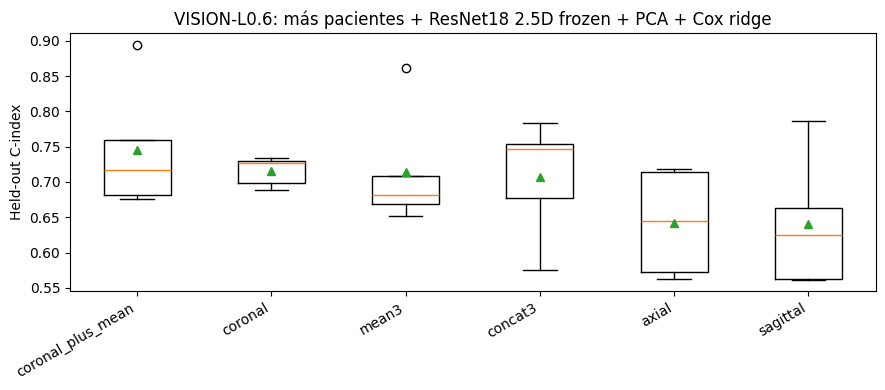

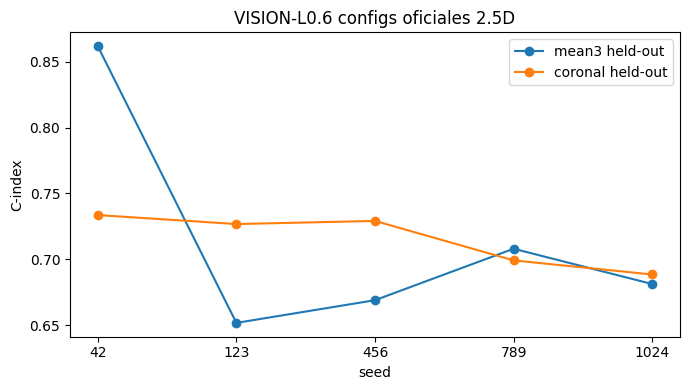

Figuras:
 - /content/drive/MyDrive/datatesis/baseline_resnet18_2p5d_exp6_official444/artifacts/fig_exp6_variant_boxplot.png
 - /content/drive/MyDrive/datatesis/baseline_resnet18_2p5d_exp6_official444/artifacts/fig_exp6_official_by_seed.png


In [14]:
# ============================================================
# 13) Resúmenes y figuras
# ============================================================
def aggregate_results(df, group_cols):
    agg = df.groupby(group_cols).agg(
        heldout_cindex_mean=('heldout_cindex','mean'), heldout_cindex_std=('heldout_cindex','std'),
        heldout_cindex_min=('heldout_cindex','min'), heldout_cindex_max=('heldout_cindex','max'),
        train_cindex_mean=('train_cindex','mean'), train_cindex_std=('train_cindex','std'),
        inner_cv_cindex_mean=('inner_cv_cindex','mean'), n=('heldout_cindex','count'),
        events_heldout_mean=('events_heldout','mean'), heldout_pairs_mean=('heldout_pairs','mean')
    ).reset_index()
    agg['gap_mean'] = agg['train_cindex_mean'] - agg['heldout_cindex_mean']
    return agg

variant_agg = aggregate_results(variant_df, ['config']).sort_values('heldout_cindex_mean', ascending=False)
official_agg = aggregate_results(official_df, ['config']).sort_values('config')

variant_agg.to_csv(ARTIFACTS_DIR / 'exp6_variant_summary_aggregate.csv', index=False)
official_agg.to_csv(ARTIFACTS_DIR / 'exp6_official_summary_aggregate.csv', index=False)

print('Resumen por variante:')
display(variant_agg)
print('Resumen oficial:')
display(official_agg)

plt.figure(figsize=(9,4))
order = variant_agg['config'].tolist()
data = [variant_df.loc[variant_df['config']==cfg, 'heldout_cindex'].values for cfg in order]
plt.boxplot(data, labels=order, showmeans=True)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Held-out C-index')
plt.title('VISION-L0.6: más pacientes + ResNet18 2.5D frozen + PCA + Cox ridge')
plt.tight_layout()
fig1 = ARTIFACTS_DIR / 'fig_exp6_variant_boxplot.png'
plt.savefig(fig1, dpi=200)
plt.show()

plt.figure(figsize=(7,4))
for cfg in [CFG['official_main_config'], CFG['official_secondary_config']]:
    sub = official_df[official_df['config']==cfg].sort_values('seed')
    plt.plot(sub['seed'].astype(str), sub['heldout_cindex'], marker='o', label=f'{cfg} held-out')
plt.ylabel('C-index')
plt.xlabel('seed')
plt.title('VISION-L0.6 configs oficiales 2.5D')
plt.legend()
plt.tight_layout()
fig2 = ARTIFACTS_DIR / 'fig_exp6_official_by_seed.png'
plt.savefig(fig2, dpi=200)
plt.show()

print('Figuras:')
print(' -', fig1)
print(' -', fig2)

## 14) Embeddings y disponibilidad para fusión

In [15]:
# ============================================================
# 14) Embeddings y disponibilidad para fusión
# ============================================================
def l2_normalize(Z):
    Z = np.asarray(Z, dtype=np.float32)
    norms = np.linalg.norm(Z, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return Z / norms

# Export contractual VISION-IN embeddings without survival fitting and without transductive PCA.
# For official_main_config='mean3', X_all has 512 ResNet18 2.5D features. We pad 512→768 and L2-normalize.
# This avoids fitting PCA/Scaler over all patients before downstream fusion splits.
main_cfg = CFG['official_main_config']
X_all = X_by_config[main_cfg].astype(np.float32)
if X_all.shape[1] > 768:
    raise ValueError(f'La config {main_cfg} tiene {X_all.shape[1]} dims; para embeddings sin fit usa mean3/coronal/axial/sagittal o añade una proyección fija.')
Z_pad = np.zeros((X_all.shape[0], 768), dtype=np.float32)
Z_pad[:, :X_all.shape[1]] = X_all
Z_norm = l2_normalize(Z_pad)

emb_rows = []
for case_id, z in zip(patients, Z_norm):
    row = {
        'case_id': case_id,
        'vision_available': 1,
        'vision_confidence': 1.0,
        'embedding_source': f"resnet18_2p5d_{main_cfg}_raw{X_all.shape[1]}_pad768_l2_no_survival_fit"
    }
    row.update({f'z{i:03d}': float(z[i]) for i in range(768)})
    emb_rows.append(row)
emb_all_usable = pd.DataFrame(emb_rows)
emb_all_usable.to_csv(ARTIFACTS_DIR / 'vision_embedding_patient_level_all_usable.csv', index=False)

availability = outcomes[['case_id','os_time','os_event']].copy()
availability['vision_available'] = availability['case_id'].isin(patients).astype(int)
availability['vision_confidence'] = availability['vision_available'].astype(float)
availability['missing_reason'] = np.where(availability['vision_available']==1, '', 'no_usable_3view_2p5d_image_in_exp6')
availability.to_csv(ARTIFACTS_DIR / 'vision_availability_for_fusion.csv', index=False)

z_cols = [c for c in emb_all_usable.columns if c.startswith('z')]
Z = emb_all_usable[z_cols].values.astype(np.float32)
norms = np.linalg.norm(Z, axis=1)
emb_check = pd.DataFrame([{
    'n_rows': emb_all_usable.shape[0],
    'n_embedding_dims': len(z_cols),
    'source_feature_dims_before_padding': X_all.shape[1],
    'nan_count': int(np.isnan(Z).sum()),
    'inf_count': int(np.isinf(Z).sum()),
    'norm_mean': float(norms.mean()),
    'norm_std': float(norms.std()),
    'norm_min': float(norms.min()),
    'norm_max': float(norms.max()),
    'uses_survival_fit': False,
    'uses_global_pca_or_scaler_fit': False,
}])
emb_check.to_csv(ARTIFACTS_DIR / 'embedding_contract_checks.csv', index=False)

display(availability['vision_available'].value_counts().rename(index={0:'missing vision',1:'vision usable'}).to_frame('patients'))
display(availability.groupby('vision_available')['os_event'].agg(['count','sum','mean']).rename(index={0:'missing vision',1:'vision usable'}))
display(emb_check)

,patients
vision_available,
missing vision,230
vision usable,214


,count,sum,mean
vision_available,,,
missing vision,230,75,0.326087
vision usable,214,64,0.299065


,n_rows,n_embedding_dims,source_feature_dims_before_padding,nan_count,inf_count,norm_mean,norm_std,norm_min,norm_max,uses_survival_fit,uses_global_pca_or_scaler_fit
0,214,768,512,0,0,1.0,1.466816e-07,1.0,1.0,False,False


## 15) Checks anti-leakage

In [16]:
# ============================================================
# 15) Checks anti-leakage
# ============================================================
check_rows = []
for seed, g in risk_df.groupby('seed'):
    for cfg, gg in g.groupby('config'):
        train_cases = set(gg.loc[gg['split']=='train', 'case_id'])
        held_cases = set(gg.loc[gg['split']=='heldout', 'case_id'])
        overlap = train_cases & held_cases
        check_rows.append({
            'seed': seed, 'config': cfg, 'n_train': len(train_cases), 'n_heldout': len(held_cases),
            'overlap_cases': len(overlap), 'status': 'OK' if len(overlap)==0 else 'LEAKAGE'
        })
checks_df = pd.DataFrame(check_rows)
checks_df.to_csv(ARTIFACTS_DIR / 'anti_leakage_checks.csv', index=False)
display(checks_df)
assert (checks_df['overlap_cases'] == 0).all(), 'LEAKAGE detectado en splits.'
assert len([c for c in emb_all_usable.columns if c.startswith('z')]) == 768, 'Embedding no tiene 768 dimensiones.'
print('[OK] splits por paciente sin overlap y embedding 768-dim')

,seed,config,n_train,n_heldout,overlap_cases,status
0,42,coronal,171,43,0,OK
1,42,mean3,171,43,0,OK
2,123,coronal,171,43,0,OK
3,123,mean3,171,43,0,OK
4,456,coronal,171,43,0,OK
5,456,mean3,171,43,0,OK
6,789,coronal,171,43,0,OK
7,789,mean3,171,43,0,OK
8,1024,coronal,171,43,0,OK
9,1024,mean3,171,43,0,OK


[OK] splits por paciente sin overlap y embedding 768-dim


## 16) Archivos principales

Comparte estos archivos para revisar resultados:

```text
baseline_resnet18_2d_exp4_1_official444/artifacts/vision_data_census.csv
baseline_resnet18_2d_exp4_1_official444/artifacts/image_extraction_attempts.csv
baseline_resnet18_2d_exp4_1_official444/slices_manifest.csv
baseline_resnet18_2d_exp4_1_official444/artifacts/exp4_variant_summary_aggregate.csv
baseline_resnet18_2d_exp4_1_official444/artifacts/exp4_official_summary_aggregate.csv
baseline_resnet18_2d_exp4_1_official444/artifacts/exp4_official_results_by_seed.csv
baseline_resnet18_2d_exp4_1_official444/artifacts/vision_availability_for_fusion.csv
baseline_resnet18_2d_exp4_1_official444/artifacts/vision_embedding_patient_level_all_usable.csv
baseline_resnet18_2d_exp4_1_official444/artifacts/anti_leakage_checks.csv
baseline_resnet18_2d_exp4_1_official444/artifacts/embedding_contract_checks.csv
```

In [17]:
# ============================================================
# 16) Resumen textual automático
# ============================================================
main = official_agg[official_agg['config'] == CFG['official_main_config']].iloc[0]
secondary = official_agg[official_agg['config'] == CFG['official_secondary_config']].iloc[0]

text = f"""
VISION-L0.6.1 used {len(patients)} imaging-available TCGA-KIRC patients aligned to the official survival cohort ({len(outcomes)} OS-valid patients).
The official {CFG['official_main_config']} ResNet18 2.5D frozen + train-only PCA + Cox ridge baseline achieved held-out C-index = {main.heldout_cindex_mean:.3f} ± {main.heldout_cindex_std:.3f}, with mean train-heldout gap = {main.gap_mean:.3f}.
The secondary {CFG['official_secondary_config']} baseline achieved held-out C-index = {secondary.heldout_cindex_mean:.3f} ± {secondary.heldout_cindex_std:.3f}, with mean train-heldout gap = {secondary.gap_mean:.3f}.
The experiment exports 768-dimensional L2-normalized VISION-IN embeddings using raw frozen ResNet18 2.5D {CFG['official_main_config']} features padded to 768 dimensions, plus an availability mask for all OS-valid patients, enabling downstream multimodal fusion with missing modalities.
""".strip()
print(text)
with open(ARTIFACTS_DIR / 'exp6_result_text.txt', 'w') as f:
    f.write(text + '\n')

print('\n[ARCHIVOS PRINCIPALES]')
for p in [
    CENSUS_CSV, EXTRACTION_ATTEMPTS_CSV, SLICES_CSV,
    ARTIFACTS_DIR / 'exp6_variant_summary_aggregate.csv',
    ARTIFACTS_DIR / 'exp6_official_summary_aggregate.csv',
    ARTIFACTS_DIR / 'exp6_official_results_by_seed.csv',
    ARTIFACTS_DIR / 'vision_availability_for_fusion.csv',
    ARTIFACTS_DIR / 'vision_embedding_patient_level_all_usable.csv',
    ARTIFACTS_DIR / 'anti_leakage_checks.csv',
    ARTIFACTS_DIR / 'embedding_contract_checks.csv',
]:
    print(' -', p)

VISION-L0.6.1 used 214 imaging-available TCGA-KIRC patients aligned to the official survival cohort (444 OS-valid patients).
The official mean3 ResNet18 2.5D frozen + train-only PCA + Cox ridge baseline achieved held-out C-index = 0.714 ± 0.085, with mean train-heldout gap = 0.111.
The secondary coronal baseline achieved held-out C-index = 0.715 ± 0.020, with mean train-heldout gap = 0.086.
The experiment exports 768-dimensional L2-normalized VISION-IN embeddings using raw frozen ResNet18 2.5D mean3 features padded to 768 dimensions, plus an availability mask for all OS-valid patients, enabling downstream multimodal fusion with missing modalities.

[ARCHIVOS PRINCIPALES]
 - /content/drive/MyDrive/datatesis/baseline_resnet18_2p5d_exp6_official444/artifacts/vision_data_census.csv
 - /content/drive/MyDrive/datatesis/baseline_resnet18_2p5d_exp6_official444/artifacts/image_extraction_attempts.csv
 - /content/drive/MyDrive/datatesis/baseline_resnet18_2p5d_exp6_official444/slices_manifest.csv